In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df_master = pd.read_csv("../data/processed/master_data.csv")
df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])
print("Loaded:", df_master.shape)

Loaded: (118434, 23)


In [4]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Daily order counts
daily_orders = df_master.groupby(
    df_master['order_purchase_timestamp'].dt.date
)['order_id'].nunique().reset_index()

daily_orders.columns = ['ds', 'y']
daily_orders['ds'] = pd.to_datetime(daily_orders['ds'])

print("Time series shape:", daily_orders.shape)
print(daily_orders.head())

Time series shape: (634, 2)
          ds  y
0 2016-09-04  1
1 2016-09-05  1
2 2016-09-13  1
3 2016-09-15  1
4 2016-10-02  1


In [6]:
# Split — 80% train, 20% test
split = int(len(daily_orders) * 0.8)
train = daily_orders[:split]
test  = daily_orders[split:]

# Train model
model = Prophet(yearly_seasonality=True, 
                weekly_seasonality=True,
                daily_seasonality=False)
model.fit(train)

print(f"Training on {len(train)} days")
print(f"Testing on {len(test)} days")

01:23:46 - cmdstanpy - INFO - Chain [1] start processing
01:23:47 - cmdstanpy - INFO - Chain [1] done processing


Training on 507 days
Testing on 127 days


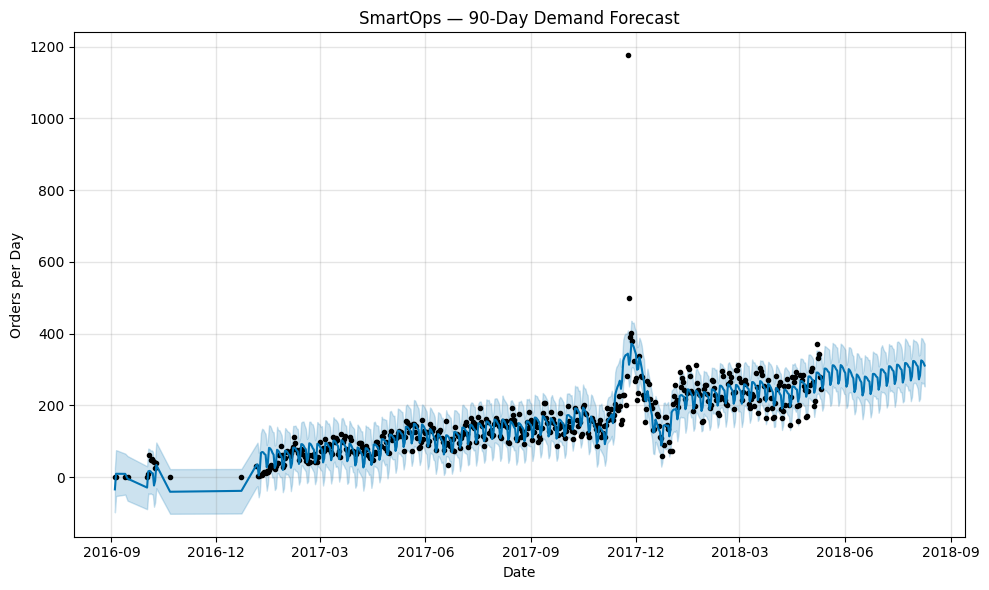

Forecast generated!


In [7]:
# Forecast 90 days into future
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Plot
fig = model.plot(forecast)
plt.title('SmartOps — 90-Day Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Orders per Day')
plt.tight_layout()
plt.savefig('../outputs/demand_forecast.png')
plt.show()

print("Forecast generated!")

In [8]:
# Compare forecast vs actual on test set
test_forecast = forecast[forecast['ds'].isin(test['ds'])][['ds','yhat']]
merged = test.merge(test_forecast, on='ds')

mae = mean_absolute_error(merged['y'], merged['yhat'])
accuracy = 100 - (mae / merged['y'].mean() * 100)

print(f"MAE: {mae:.2f} orders/day")
print(f"Forecast Accuracy: {accuracy:.1f}%")
print("\nModule 1 Complete!")

MAE: 81.48 orders/day
Forecast Accuracy: 61.5%

Module 1 Complete!


In [9]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv(
    '../data/processed/demand_forecast.csv', index=False)
print("Forecast saved!")

Forecast saved!
